# Introduction to Mathematical Modelling

**by Dr Kamil Erguler**  
Climate and One Health Group  
CARE-C - The Cyprus Institute

---

[Previous (Parameters)](https://veclim.com/tutorials-viewer/localfile/MathMod/T02_IMM_parameters.ipynb) --- Next (?)


## Thermal performance curves — Part 1

Temperature is an important driver of metabolism, especially in organisms whose body temperature depends strongly on the surrounding environment. Many insects, reptiles, amphibians, fish, and microorganisms fall into this broad category. They are often described as ectotherms, because they rely largely on external sources of heat, or poikilotherms, because their internal temperature can vary substantially.

One way to study this relationship is to measure a physiological process, such as growth, development, reproduction, or survival, at different constant temperatures. Each measurement gives us one point: a temperature and the corresponding level of performance.

Once we have such measurements, we can try to describe them with a mathematical equation. This allows us to summarise the observations, fill in values between measured temperatures, and make predictions under new conditions.

<a href="https://doi.org/10.1371/journal.pone.0153343" target="_blank" rel="noopener noreferrer"><strong>Corkrey</strong></a> and colleagues published a comprehensive analysis of temperature–growth relationships in 2016. Let's examine a small part of their data for the common gut bacterium, *Escherichia coli*, and see what kind of model we can build from it.

In [2]:
# S1 Data - Corkrey R, McMeekin TA, Bowman JP, Ratkowsky DA, Olley J, Ross T (2016) 
# The Biokinetic Spectrum for Temperature. PLoS ONE 11(4): e0153343. 
# https://doi.org/10.1371/journal.pone.0153343

Corkrey <- read.csv("https://doi.org/10.1371/journal.pone.0153343.s004")

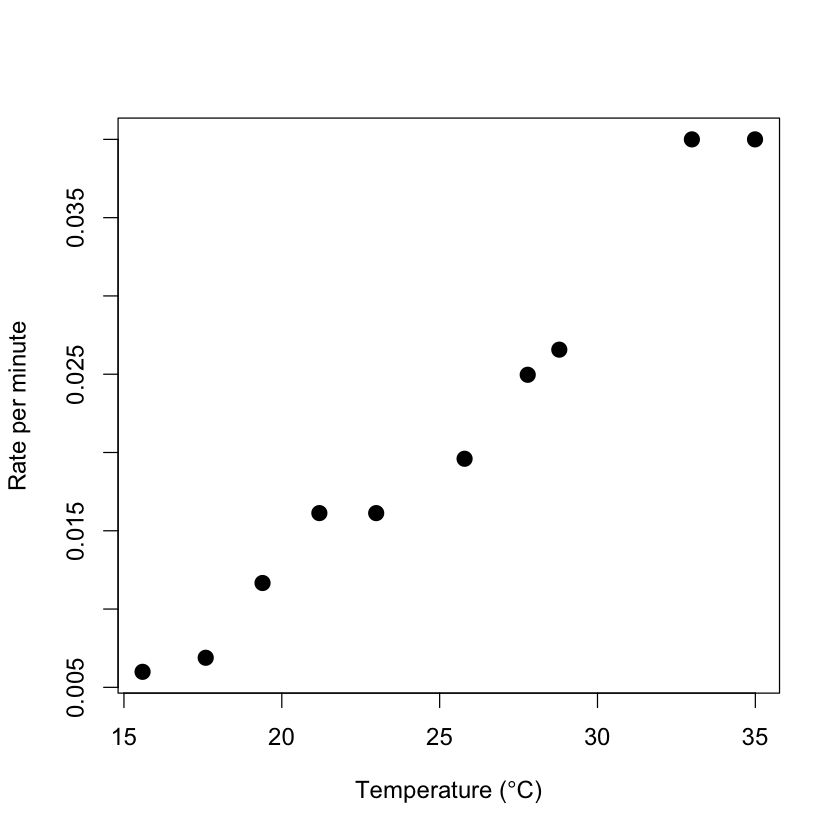

In [3]:
d <- Corkrey[
  (Corkrey$binomial.name == "Escherichia coli") &
    (Corkrey$strain.code == 547) &
    (Corkrey$T.C >= 15) &
    (Corkrey$T.C <= 35),
]
d <- d[order(d$T.C), ]
d <- d[round(seq(1, nrow(d), length.out = 10)), ]

par(bg = "white", cex = 1.2)

plot(d$T.C, d$rate.per.minute, t = "p", pch = 16, cex=1.5,
     xlab = expression("Temperature ("*degree*C*")"),
     ylab = "Rate per minute")

From this plot, it seems that there may be a roughly linear relationship between bacterial growth performance and temperature. When it is cold, *E. coli* grows slowly, and therefore food may take longer to spoil. This is comforting in winter, but you should not leave food on the counter for long in summer.

Let us propose a model for this relationship, and call it $M$.

Based on what we have seen so far, we may describe the temperature–performance relationship by

$$
\rho(T) = aT + b,
$$

where $\rho(T)$ is the temperature-dependent growth rate, $T$ is temperature, $a$ controls how strongly the growth rate increases with temperature, and $b$ is an offset.

Let us restrict $a$ to non-negative values. This means that $M$ is not just any linear model; it is the positive-association version of a linear relationship model structure. A separate model version could instead focus on the negative domain of $a$, representing the hypothesis that growth rate decreases as temperature increases. Here, to avoid complicating things too early, we will consider only the positive-association case.

---

An obvious limitation is that this model describes a straight line: one predicted performance value for each temperature, with performance changing at a constant rate as temperature changes. From the plot, it is clear that no single straight line can pass through all the points.

Why not? Experimental error? Differences in conditions other than temperature? Natural variability among replicate measurements?

It could be many things.

So, we need to account for variability in the observations. Otherwise, the model cannot match the data. We can introduce this variability with a noise term from a chosen probability distribution:

$$
\rho(T) = aT + b + \epsilon,
$$

where $\epsilon$ is a random number. Let us say that it is normally distributed around zero, with variance $\sigma^2$:

$$
\epsilon \sim N(0, \sigma^2).
$$

Therefore, $M$ has three parameters, $a$, $b$, and $\sigma$, and gives a distribution of possible growth rates around the straight-line relationship.

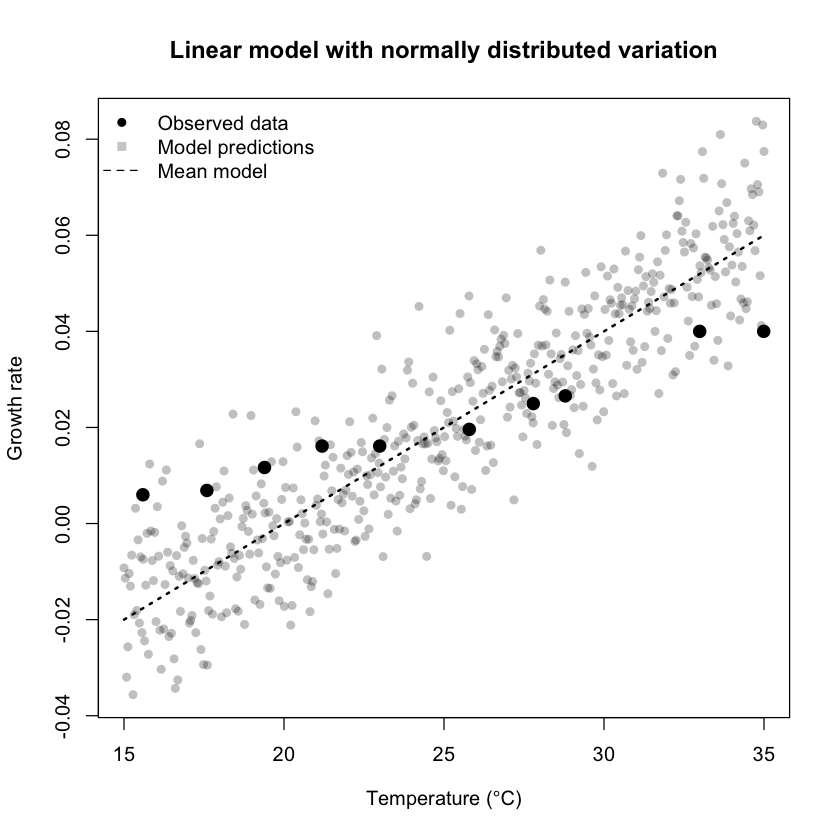

In [ ]:
# Parameters for the line
a <- 0.004
b <- -0.08
sigma <- 0.01

# Temperatures
Tseq <- seq(15, 35, length.out = 500)

# Straight-line relationship
rho_mean <- a * Tseq + b

rho_sim <- a * Tseq + b + rnorm(length(Tseq), mean = 0, sd = sigma)

par(bg = "white")

plot(Tseq, rho_sim,
     pch = 16,
     col = adjustcolor("black", alpha.f = 0.25),
     xlab = expression("Temperature ("*degree*C*")"),
     ylab = "Growth rate",
     main = "Linear model with normally distributed variation")

lines(Tseq, rho_mean, lty=3, lwd = 2)

points(d$T.C, d$rate.per.minute, t = "p", pch = 16, cex=1.5,
     xlab = expression("Temperature ("*degree*C*")"),
     ylab = "Rate per minute")

legend("topleft",
       legend = c("Observed data", "Model predictions", "Mean model"),
       pch = c(16, 15, NA),
       lty = c(NA, NA, 2),
       lwd = c(NA, NA, 1),
       col = c("black", adjustcolor("grey50", alpha.f = 0.4), "black"),
       bty = "n")

It seems that, with $a = 0.004$, $b = -0.08$, and $\sigma = 0.01$, our model does not quite match the observations. We can quantify this mismatch using the likelihood of the observations, $\delta$, defined as the probability density assigned to the data by the model under a given parameter configuration.

Strictly speaking, for **discrete observations**, the likelihood is the **probability** assigned to the data. For **continuous observations**, the likelihood is the **probability density** assigned to the data. Since growth rate is treated as a continuous variable in this example, we calculate the likelihood using a probability density:

$$
P(\delta \mid M, \theta).
$$

For any given temperature, $T$, the model generates a random growth rate with mean $aT + b$ and standard deviation $\sigma$. Now consider one data point, where the temperature is $T_i$ and the measured growth rate is $\delta_i$. The likelihood of this observation is the probability density that the model assigns to $\delta_i$ at temperature $T_i$:

$$
P(\delta_i \mid T_i, M, \theta)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[
-\frac{(\delta_i - (aT_i+b))^2}{2\sigma^2}
\right].
$$

Assuming that the observations are independent of each other, the likelihood of the full dataset is the product of these probability densities:

$$
P(\delta \mid M, \theta)
=
\prod_i
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[
-\frac{(\delta_i - (aT_i+b))^2}{2\sigma^2}
\right].
$$

In [4]:
# We work with the log-likelihood for numerical stability and to avoid underflow issues with small probabilities.
log_likelihood <- function(T, rho, a, b, sigma) {
  if (!is.finite(sigma) || sigma <= 0) {
    return(-Inf)
  }
  
  sum(dnorm(rho, mean = a * T + b, sd = sigma, log = TRUE))
}

# This is the likelihood function, which is the exponential of the log-likelihood.
likelihood <- function(T, rho, a, b, sigma) {
  exp(log_likelihood(T, rho, a, b, sigma))
}

lik <- likelihood(
  T = d$T.C,
  rho = d$rate.per.minute,
  a = 0.004,
  b = -0.08,
  sigma = 0.01
)
print(paste("Likelihood:", lik))

log.lik <- log_likelihood(
  T = d$T.C,
  rho = d$rate.per.minute,
  a = 0.004,
  b = -0.08,
  sigma = 0.01
)
print(paste("Log-Likelihood:", log.lik))

[1] "Likelihood: 1013938184234.82"
[1] "Log-Likelihood: 27.6448630569462"



## A note on probability density

You may notice that the likelihood can sometimes be a very large number. This does not mean that the model assigns a very large probability to the observations. In this case, the likelihood is calculated using probability densities, and probability densities are not probabilities. For continuous random variables, probabilities are assigned to intervals, not to exact values.

To see why, imagine drawing a random number from a uniform distribution between 0 and 1. The probability density is the same at 0.5 and at 0.5001. The probability of drawing a number within the interval $[0.49999, 0.50001]$ is also the same as the probability of drawing a number within $[0.50009, 0.50011]$, because the two intervals have the same width. However, the probability of drawing exactly 0.5 is zero. To include only 0.5 and no other real number, the interval would have to have zero width.


## Setting up priors

How do we quantify our prior belief about the three parameters?

$$
\theta = (a,b,\sigma)
$$

Is there a reason to lean towards a certain region of parameter space?

Testing a specific hypothesis can be a reason to do so. For instance, we restricted $a$ to non-negative values to represent the hypothesis that growth rate does not decrease as temperature increases.

We must also restrict $\sigma$ to positive values, because it represents the standard deviation of the noise term, and a standard deviation must be greater than zero.

The easiest way to express these restrictions is to assign uniform prior distributions with predefined ranges. Let us choose the following:

$$
\begin{array}{lcl}
P(a) &=& U(a \mid \min=0,\max=0.01),\\
P(b) &=& U(b \mid \min=-0.2,\max=0.2),\\
P(\sigma) &=& U(\sigma \mid \min=0.0001,\max=0.10).
\end{array}
$$

These priors do not favour any particular value within the allowed ranges. They simply define the part of parameter space that this model is allowed to explore.

Using the likelihood and the prior, we can define the unnormalised posterior density:

$$
P(\theta \mid \delta, M) \propto P(\delta \mid \theta, M)P(\theta \mid M).
$$

In the code, we will work with the log of the unnormalised posterior for numerical stability:

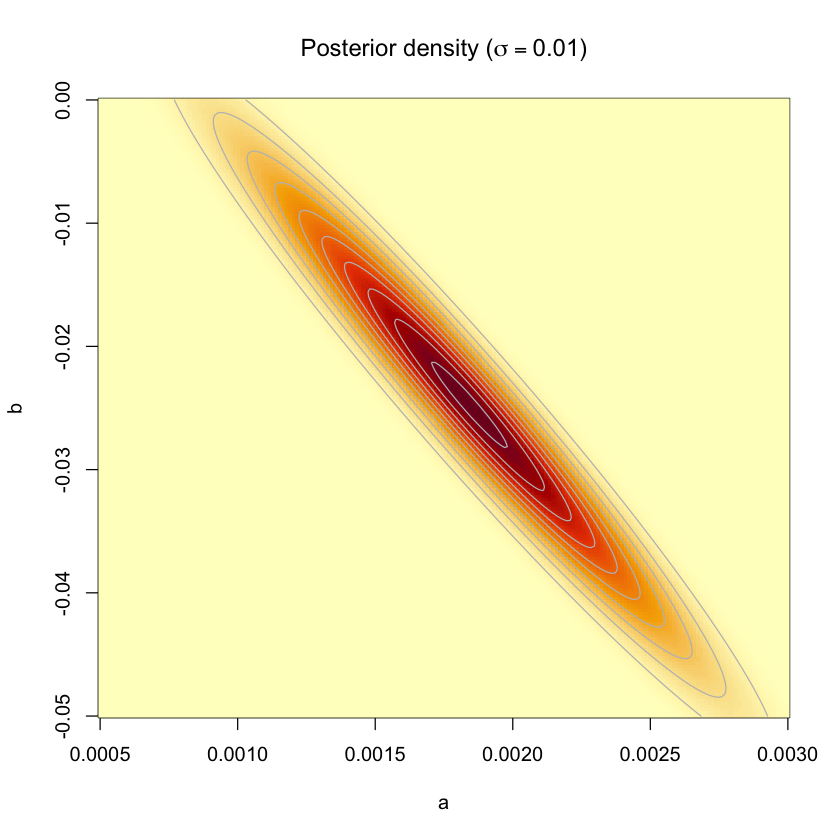

In [ ]:
log_prior <- function(a, b, sigma,
                      a_range = c(0, 0.01),
                      b_range = c(-0.20, 0.20),
                      sigma_range = c(0.0001, 0.10)) {
  
  if (a < a_range[1] || a > a_range[2]) return(-Inf)
  if (b < b_range[1] || b > b_range[2]) return(-Inf)
  if (sigma < sigma_range[1] || sigma > sigma_range[2]) return(-Inf)
  
  -log(a_range[2] - a_range[1]) -
    log(b_range[2] - b_range[1]) -
    log(sigma_range[2] - sigma_range[1])
}

log_posterior <- function(pr) {
  T <- d$T.C
  rho <- d$rate.per.minute

  a <- pr["a"]
  b <- pr["b"]
  sigma <- pr["sigma"]
  
  log_prior(a, b, sigma) + log_likelihood(T, rho, a, b, sigma)
}

# A 2D plot of the unnormalised posterior density over a grid of (a, b) values, keeping sigma fixed at 0.01.
theta1 <- seq(0.0005, 0.003, length.out = 200)
theta2 <- seq(-0.05, 0.0, length.out = 200)

sigma_fixed <- 0.01

## Posterior surface
posterior_z <- outer(theta1, theta2, Vectorize(function(a, b) {
    exp(log_posterior(c(a = a, b = b, sigma = sigma_fixed)))
}) )

par(bg = "white")

image(theta1, theta2, posterior_z,
      col = hcl.colors(100, "YlOrRd", rev = TRUE),
      xlab = "a", ylab = "b", main = expression("Posterior density (" * sigma == 0.01 * ")"), axes = TRUE)
contour(theta1, theta2, posterior_z,
        levels = pretty(range(posterior_z), n = 8)[-1], col="gray",
        add = TRUE, drawlabels = FALSE, lty = 1, lwd = 1.0)

The posterior density plot shows which combinations of $a$ and $b$ are most supported by the observations, while keeping $\sigma = 0.01$ fixed. Each point in the $(a,b)$ parameter grid defines one possible model relationship:

$$
\rho(T) = aT + b + \epsilon.
$$

However, not all parameter combinations are equally supported by the observations. Within the allowed parameter range, we observe a strong dependence between $a$ and $b$. Larger values of $a$ must be paired with lower values of $b$ to keep the line close to the observed data. In other words, $a$ and $b$ show a negative association in the posterior.

The negative values of $b$ should be interpreted cautiously. The intercept is the predicted growth rate at $T=0$, which is outside the temperature range shown here. In this example, $b$ mainly helps position the line within the observed temperature range, rather than carrying a direct biological meaning.


## Markov chain Monte Carlo (MCMC)

So far, we have been quite lucky. We were able to search through the interesting parts of parameter space, identify the posterior mode, and calculate the expected relationship between temperature and growth rate, while still keeping $\sigma$ fixed.

MCMC offers a powerful alternative. Instead of evaluating the posterior over a predefined grid, we allow the algorithm to move through parameter space step by step. After an initial exploration period, the algorithm generates a sequence of parameter configurations that represents the posterior distribution. Regions with higher posterior density are visited more often, while lower-density regions are visited less often.

### The Metropolis–Hastings algorithm

Metropolis–Hastings is an MCMC algorithm based on proposals and acceptances. At each step, it proposes a new parameter configuration near the current one, then decides whether to move there by comparing the current and proposed posterior support.

This accept-or-reject rule turns an ordinary random walk into a sampler for the posterior distribution.

Here, let's begin the chain at an initial parameter configuration, for example

$$
\theta = (a,b,\sigma) = (0.004, -0.08, 0.01),
$$

At each step, the algorithm proposes a small random change to the current parameter values,

$$
\theta' = (a',b',\sigma').
$$

This proposal is drawn from a **proposal distribution**, which we can write as

$$
q(\theta' \mid \theta).
$$

This means: given the current configuration $\theta$, the proposal distribution tells us how likely we are to propose the new configuration $\theta'$.

We then compare the posterior value of the proposed configuration with the posterior value of the current configuration. If the proposal is accepted, we move to the new position and make another proposal from there. If it is rejected, we stay where we are and try again.

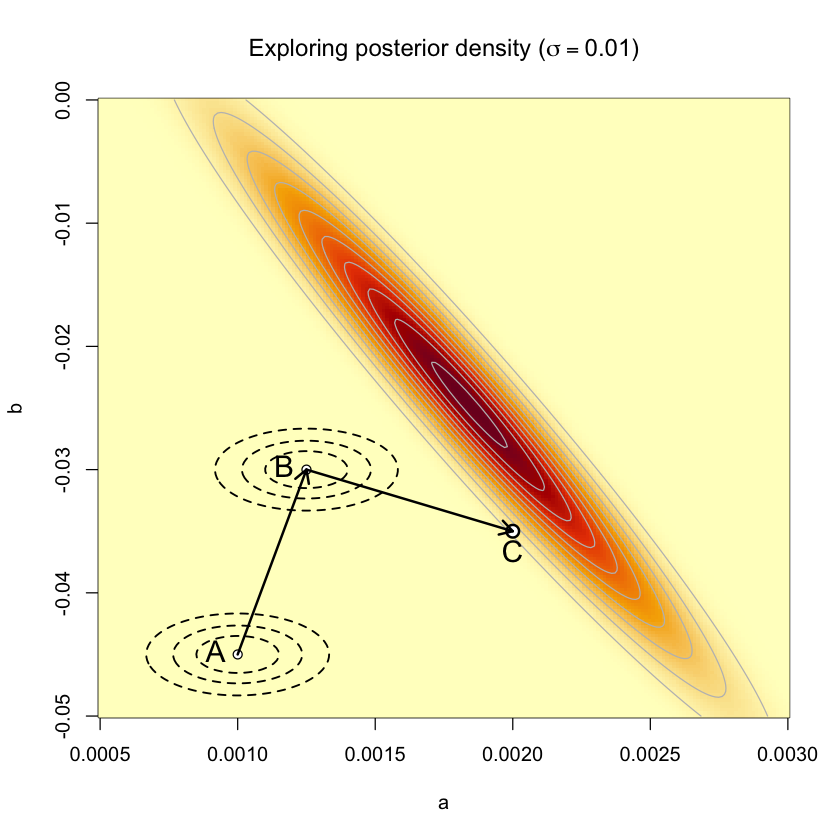

In [ ]:
A <- c(theta1 = 0.001, theta2 = -0.045)
B <- c(theta1 = 0.00125, theta2 = -0.03)
C <- c(theta1 = 0.002, theta2 = -0.035)

## Proposal distributions
proposal_Az <- outer(
  dnorm(theta1, mean = A[1], sd = 0.0002),
  dnorm(theta2, mean = A[2], sd = 0.002),
  `*`
)
proposal_Bz <- outer(
  dnorm(theta1, mean = B[1], sd = 0.0002),
  dnorm(theta2, mean = B[2], sd = 0.002),
  `*`
)

## Plot
par(bg = "white")

image(theta1, theta2, posterior_z,
      col = hcl.colors(100, "YlOrRd", rev = TRUE),
      xlab = "a", ylab = "b", main = expression("Exploring posterior density (" * sigma == 0.01 * ")"), axes = TRUE)
contour(theta1, theta2, posterior_z,
        levels = pretty(range(posterior_z), n = 8)[-1], col="gray",
        add = TRUE, drawlabels = FALSE, lty = 1, lwd = 1.0)

## Proposal distribution as isodensity contours
contour(theta1, theta2, proposal_Az,
        levels = pretty(range(proposal_Az), n = 4)[-1],
        add = TRUE, drawlabels = FALSE, lty = 2, lwd = 1.5)
contour(theta1, theta2, proposal_Bz,
        levels = pretty(range(proposal_Bz), n = 4)[-1],
        add = TRUE, drawlabels = FALSE, lty = 2, lwd = 1.5)

## Points A and B
points(A[1], A[2], pch = 21, bg = "white", cex = 1.0, lwd = 1)
points(B[1], B[2], pch = 21, bg = "white", cex = 1.0, lwd = 1)
points(C[1], C[2], pch = 21, bg = "white", cex = 1.4, lwd = 2)

## Labels
text(A[1], A[2], labels = "A", pos = 2, cex = 1.5)
text(B[1], B[2], labels = "B", pos = 2, cex = 1.5)
text(C[1], C[2], labels = "C", pos = 1, cex = 1.5)

## Arrow from A to B to C
arrows(A[1], A[2], B[1], B[2], length = 0.12, lwd = 2)
arrows(B[1], B[2], C[1], C[2], length = 0.12, lwd = 2)

---

Whether the proposal is accepted or not depends on the relative posterior values of the current configuration, $P(\theta \mid \delta, M)$, and the proposed configuration, $P(\theta' \mid \delta, M)$, as well as the relative probabilities of proposing $\theta'$ from $\theta$ and proposing $\theta$ from $\theta'$.

The posterior part is intuitive: we want the sampler to spend more time in high-density regions of the posterior. Therefore, proposals that increase the posterior value are more likely to be accepted.

The proposal part is a little trickier. If it is easier to propose the move $\theta \rightarrow \theta'$ than the reverse move $\theta' \rightarrow \theta$, then accepting the move too readily would bias the sampler: it would spend too much or too little time in some parts of parameter space simply because of how proposals are generated. The Metropolis–Hastings correction offsets this imbalance.

---

We can formulate the above criteria into an **acceptance ratio**, written as

$$
R =
\frac{
P(\theta' \mid \delta, M)
}{
P(\theta \mid \delta, M)
}
\frac{
q(\theta \mid \theta')
}{
q(\theta' \mid \theta)
}.
$$

This is equivalent to defining an **acceptance probability** as

$$
\alpha = \min(1, R).
$$

When $R > 1$, the proposed configuration is always accepted. When $R < 1$, the proposed configuration is accepted with probability $R$. For example, if the posterior value at the proposed configuration is half as large as the posterior value at the current configuration, and the proposal distribution is symmetric, then $R = 0.5$, $\alpha = 0.5$, and the proposal is accepted with probability 50%.

This is the part that prevents the sampler from only climbing uphill. Occasionally accepting worse parameter configurations allows it to explore the surrounding parameter space instead of getting stuck near the first good configuration it finds.

After many steps, the sampler spends more time in regions of parameter space with higher posterior probability. The resulting sequence of parameter values is an approximation of the posterior distribution.


### Working with ratios

Using Bayes' rule, we can expand the posterior terms in the acceptance ratio:

$$
R =
\frac{
P(\theta' \mid \delta, M)
}{
P(\theta \mid \delta, M)
}
\frac{
q(\theta \mid \theta')
}{
q(\theta' \mid \theta)
}.
$$

For the current configuration,

$$
P(\theta \mid \delta, M)
=
\frac{
P(\delta \mid \theta, M)P(\theta \mid M)
}{
P(\delta \mid M)
},
$$

and for the proposed configuration,

$$
P(\theta' \mid \delta, M)
=
\frac{
P(\delta \mid \theta', M)P(\theta' \mid M)
}{
P(\delta \mid M)
}.
$$

Substituting these into the acceptance ratio gives

$$
R =
\frac{
\frac{
P(\delta \mid \theta', M)P(\theta' \mid M)
}{
P(\delta \mid M)
}
}{
\frac{
P(\delta \mid \theta, M)P(\theta \mid M)
}{
P(\delta \mid M)
}
}
\frac{
q(\theta \mid \theta')
}{
q(\theta' \mid \theta)
}.
$$

The model evidence, $P(\delta \mid M)$, appears in both the numerator and the denominator, so it cancels out:

$$
R =
\frac{
P(\delta \mid \theta', M)P(\theta' \mid M)
}{
P(\delta \mid \theta, M)P(\theta \mid M)
}
\frac{
q(\theta \mid \theta')
}{
q(\theta' \mid \theta)
}.
$$

This is useful because we do not need to calculate the evidence explicitly. We only need the likelihood, the prior, and the proposal probabilities.

If the proposal distribution is symmetric, such as a normal random-walk proposal with fixed standard deviations, then the move $\theta \rightarrow \theta'$ and the reverse move $\theta' \rightarrow \theta$ are equally likely:

$$
q(\theta \mid \theta') = q(\theta' \mid \theta).
$$

In that case, the proposal terms cancel, and the acceptance ratio can be written as

$$
R =
\frac{
P(\delta \mid \theta', M)P(\theta' \mid M)
}{
P(\delta \mid \theta, M)P(\theta \mid M)
}.
$$

This is the ratio of the unnormalised posterior densities we calculated earlier.

If the prior is uniform, and both the current and proposed configurations are inside the allowed parameter ranges, then

$$
P(\theta' \mid M) = P(\theta \mid M),
$$

so the prior terms also cancel. In that case, we are left with the ratio of the likelihoods:

$$
R =
\frac{
P(\delta \mid \theta', M)
}{
P(\delta \mid \theta, M)
}.
$$

Therefore, with a symmetric proposal distribution and uniform priors, Metropolis–Hastings accepts or rejects proposed moves by comparing how much likelihood the proposed and current parameter configurations assign to the observations.

In [6]:
# An example Metropolis-Hastings algorithm implementation
metropolis.hastings <- function(f_log_posterior,
                      n_iter = 10000,
                      start = c(a = 0.004, b = -0.08, sigma = 0.01),
                      step = c(a = 0.0002, b = 0.002, sigma = 0.001)) {
  
  chain <- matrix(NA, nrow = n_iter, ncol = 4)
  colnames(chain) <- c("a", "b", "sigma", "log_posterior")
  
  current <- start
  current_log_post <- f_log_posterior(current)
  
  accepted <- 0
  
  for (i in seq_len(n_iter)) {
    
    proposal <- current + rnorm(3, mean = 0, sd = step)
    names(proposal) <- names(current)
    
    proposal_log_post <- f_log_posterior(proposal)
    
    log_acceptance_ratio <- proposal_log_post - current_log_post
    
    if (log(runif(1)) < log_acceptance_ratio) {
      current <- proposal
      current_log_post <- proposal_log_post
      accepted <- accepted + 1
    }
    
    chain[i, ] <- c(
      current["a"],
      current["b"],
      current["sigma"],
      current_log_post
    )
  }
  
  chain <- as.data.frame(chain)
  attr(chain, "acceptance_rate") <- accepted / n_iter
  
  chain
}

# Run the sampler for 20,000 iterations
samples <- metropolis.hastings(
  f_log_posterior = log_posterior,
  n_iter = 20000
)

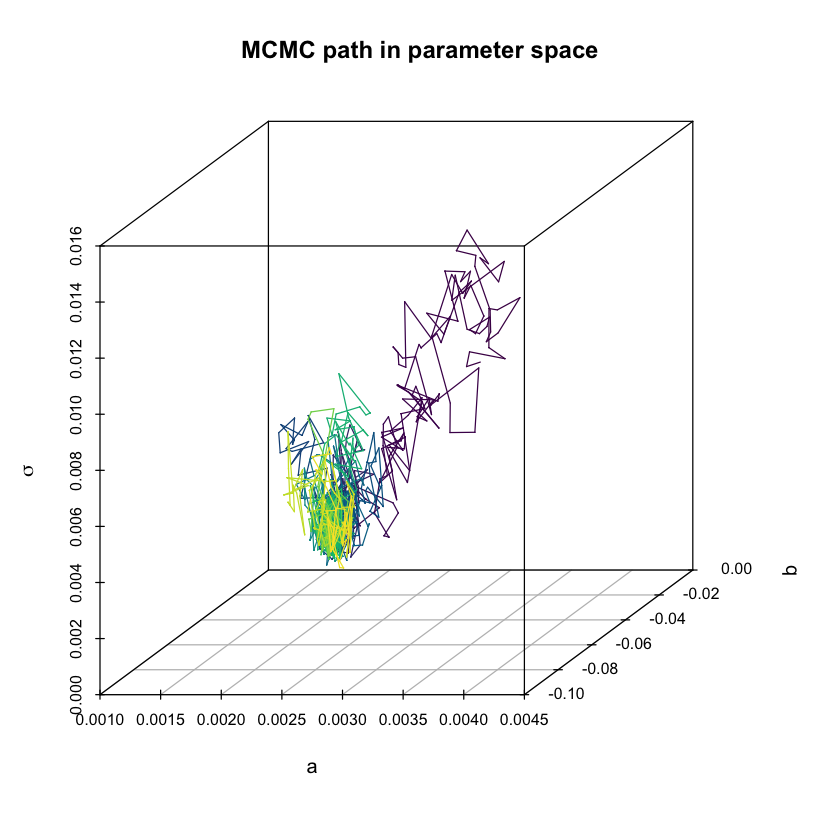

In [7]:
library(scatterplot3d)

# Let's take the first 5000 samples to visualise the path in parameter space
mhpath <- samples[1:5000, ]

par(bg = "white")

# Colour gradient along the chain
cols <- hcl.colors(nrow(mhpath) - 1, "Viridis")

# Empty 3D plot
s3d <- scatterplot3d(mhpath$a,
                     mhpath$b,
                     mhpath$sigma,
                     type = "n",
                     xlab = "a",
                     ylab = "b",
                     zlab = expression(sigma),
                     main = "MCMC path in parameter space")

# Project 3D coordinates to 2D plotting coordinates
pts <- s3d$xyz.convert(mhpath$a, mhpath$b, mhpath$sigma)

# Draw coloured line segments
for (i in 1:(nrow(mhpath) - 1)) {
  segments(pts$x[i], pts$y[i],
           pts$x[i + 1], pts$y[i + 1],
           col = cols[i],
           lwd = 1)
}


### Burn-in and thinning

The Metropolis–Hastings sampler generates a sequence of parameter configurations, called a Markov chain. However, we should not necessarily treat every sampled value as an independent draw from the posterior distribution.

Two practical issues are important.

First, the chain starts from an initial parameter configuration. Early in the run, the sampler may still be moving away from this starting point and towards the high-density region of the posterior. These early samples can therefore depend strongly on the initial values. To reduce this effect, we usually remove an initial part of the chain. This discarded part is called the **burn-in**. A common rule of thumb is to discard the first quarter of the output, although in practice this should depend on how quickly the chain appears to settle.

Second, consecutive samples in an MCMC chain are not independent. Each proposal is made from the current position, so nearby iterations tend to be correlated with each other. This is called **autocorrelation**. If autocorrelation is high, the chain may contain many samples, but less independent information than the number of rows suggests.

One simple way to reduce autocorrelation among retained samples is **thinning**. This means keeping only every $k$-th sample from the chain. For example, with $k=10$, we keep every tenth sample and discard the rest.

More formal MCMC analyses use diagnostics such as trace plots, autocorrelation plots, effective sample size, and comparisons among multiple chains started from different initial values.

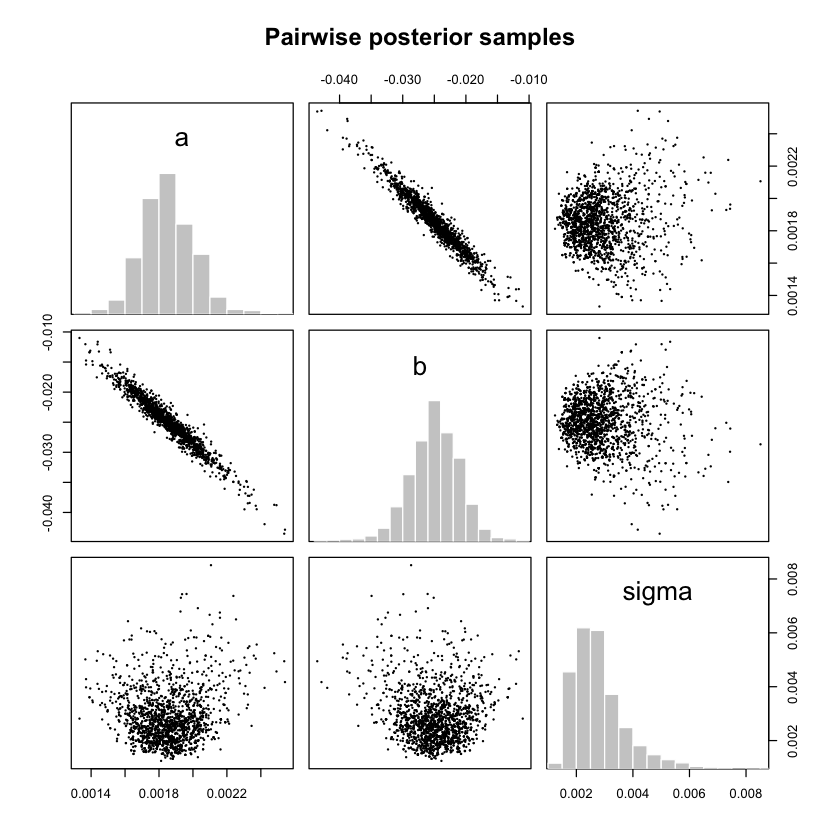

In [8]:
panel_hist <- function(x, ...) {
  usr <- par("usr")
  on.exit(par(usr = usr))
  par(usr = c(usr[1:2], 0, 1.5))
  
  h <- hist(x, plot = FALSE)
  y <- h$counts / max(h$counts)
  
  rect(h$breaks[-length(h$breaks)],
       0,
       h$breaks[-1],
       y,
       col = "grey80",
       border = "white")
}

panel_points <- function(x, y, ...) {
  points(x, y, pch = 16, cex = 0.4)
}

# Burn-in to discard initial samples before convergence
burnin <- 1000
post <- samples[(burnin + 1):nrow(samples), ]

# Thinning to reduce overplotting in the pairs plot
ii <- seq(1, nrow(post), by = 10)
post_thin <- post[ii, ]

par(bg = "white")

pairs(post_thin[, c("a", "b", "sigma")],
      lower.panel = panel_points,
      upper.panel = panel_points,
      diag.panel = panel_hist,
      main = "Pairwise posterior samples")


## Posterior predictive distribution

The posterior predictive distribution of our model, $M$, is obtained by averaging the model predictions over all possible parameter configurations, weighted by the posterior support for each configuration.

This can be understood as adding another layer of variability to an already **stochastic** model. Our model $M$ is stochastic because it describes a distribution of possible growth rates, rather than a single growth rate. It does this using three parameters: $a$ and $b$, which describe the linear relationship with temperature, and $\sigma$, which describes the variability around this relationship.

The model would have been simpler if it were **deterministic**: that is, if it always generated the same growth rate for the same temperature. But then it would not explain the variability we see in the data.

For each parameter configuration,

$$
\theta_j = (a_j, b_j, \sigma_j),
$$

we obtain a different linear relationship and a different probability distribution for growth rate:

$$
\rho_j(T) = a_jT + b_j + \epsilon_j,
$$

where

$$
\epsilon_j \sim N(0,\sigma_j^2).
$$

The **posterior predictive distribution** is defined by the integral

$$
P(\rho(T) \mid T, \delta, M)
=
\int
P(\rho(T) \mid T, \theta, M)
P(\theta \mid \delta, M)
\,d\theta .
$$

This integral averages the model predictions over all possible parameter configurations, weighted by their posterior support, $P(\theta \mid \delta, M)$. As a result, we obtain a single predictive distribution supported by the data, rather than a prediction based on one particular parameter configuration.


### Monte Carlo integration

We can approximate this integral using samples from the MCMC chain.

If we have $J$ posterior samples,

$$
\theta_j = (a_j,b_j,\sigma_j),
$$

then the posterior predictive density can be approximated by

$$
P(\rho(T) \mid T, \delta, M)
\approx
\frac{1}{J}
\sum_{j=1}^{J}
P(\rho(T) \mid T, \theta_j, M).
$$

For our model,

$$
P(\rho(T) \mid T, \theta_j, M)
=
N(\rho(T) \mid a_jT+b_j, \sigma_j^2).
$$

So, at each temperature, we calculate the normal density implied by every posterior sample and then average these densities. This is **Monte Carlo integration**: the integral over parameter space is replaced by an average over sampled parameter values.

To illustrate this, we plot the posterior predictive density at $T=25^{\circ}\mathrm{C}$. This density is the average of many normal densities, one from each posterior sample. In other words, it is a mixture of normals.

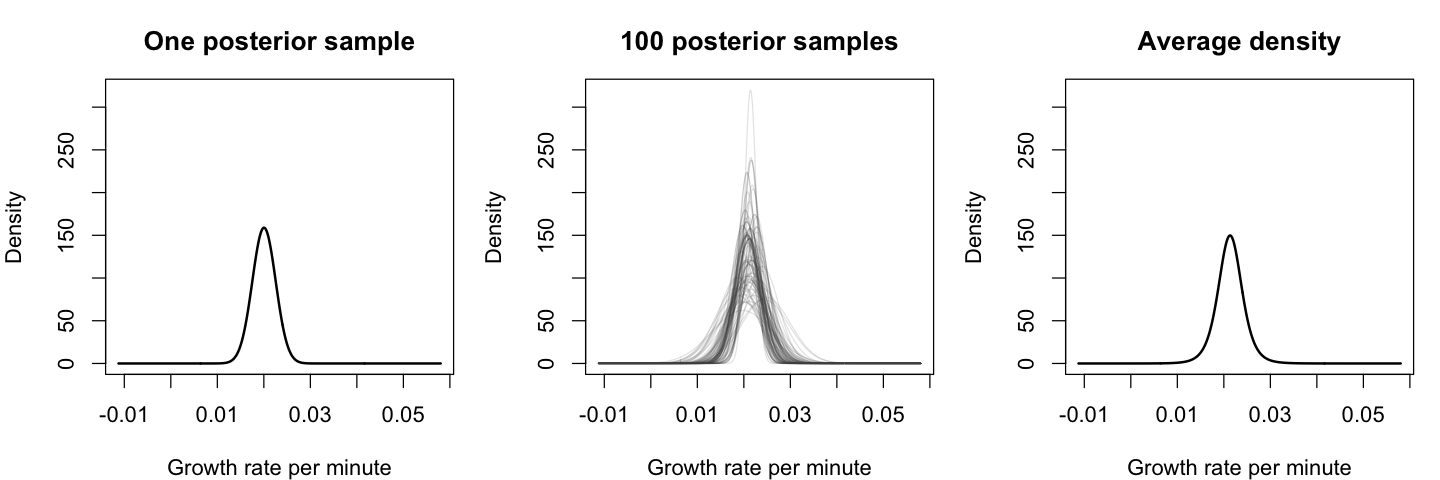

In [25]:
## Three-panel illustration of posterior predictive density at T = 25

T0 <- 25

## Number of individual posterior samples to show in panel 2
N_show <- 100

## Means and standard deviations implied by retained samples at T = 25
mu_all <- post_thin$a * T0 + post_thin$b
sd_all <- post_thin$sigma

## Growth-rate grid for plotting densities
rho_grid <- seq(min(mu_all - 4 * sd_all), max(mu_all + 4 * sd_all), length.out = 500)

## Panel 1: density from first retained MCMC sample
mu_1 <- mu_all[1]
sd_1 <- sd_all[1]

dens_1 <- dnorm(rho_grid, mean = mu_1, sd = sd_1)

## Panel 2: densities from 100 retained samples
dens_show <- sapply(1:N_show, function(j) {
  dnorm(rho_grid, mean = mu_all[j], sd = sd_all[j])
})

## Panel 3: average density over all retained samples
dens_mean <- sapply(rho_grid, function(rho_val) {
  mean(dnorm(rho_val, mean = mu_all, sd = sd_all))
})

## Common y-axis range
ylim_all <- range(dens_1, dens_show, dens_mean)

old_options <- options(repr.plot.width = 12,
                       repr.plot.height = 4)

par(bg = "white", mfrow = c(1, 3), mar = c(4, 4, 3, 1), cex = 1.1)

## Panel 1
plot(rho_grid, dens_1,
     type = "l", lwd = 2, ylim = ylim_all,
     xlab = "Growth rate per minute", ylab = "Density", main = "One posterior sample")

## Panel 2
plot(rho_grid, dens_show[, 1],
     type = "n", ylim = ylim_all, 
     xlab = "Growth rate per minute", ylab = "Density", main = "100 posterior samples")

for (j in seq_len(ncol(dens_show))) {
  lines(rho_grid, dens_show[, j], col = adjustcolor("grey30", alpha.f = 0.15), lwd = 1)
}

## Panel 3
plot(rho_grid, dens_mean,
     type = "l", lwd = 2, ylim = ylim_all,
     xlab = "Growth rate per minute", ylab = "Density", main = "Average density")

options(old_options)
par(mfrow = c(1, 1))

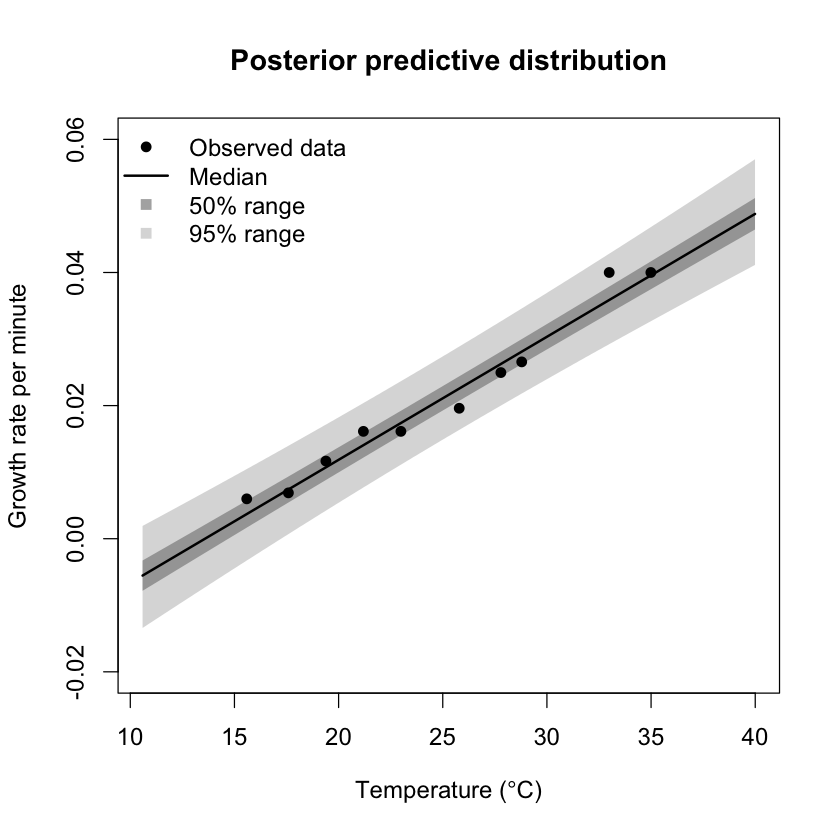

In [ ]:
## Finally, we repeat the Monte Carlo integration over a range of temperature values
## to obtain the posterior predictive density

## This function takes a density vector (dens) 
## and the corresponding grid (rho_grid), and returns the quantiles 
## corresponding to the specified probabilities (probs)
get_interval <- function(dens, rho_grid, probs = c(0.025, 0.25, 0.5, 0.75, 0.975)) {
  
  drho <- diff(rho_grid)[1]
  cdf <- cumsum(dens) * drho
  cdf <- cdf / max(cdf)
  
  approx(cdf, rho_grid, xout = probs, ties = "ordered")$y
}

## Choose a wide growth-rate grid that covers most of the predictive distribution
rho_grid <- seq(-0.2, 0.2, length.out = 800)

## Calculate the average density for every temperature
pred_density <- matrix(NA, nrow = length(Tseq), ncol = length(rho_grid))
for (i in seq_along(Tseq)) {
  Tval <- Tseq[i]
  
  mu_j <- post_thin$a * Tval + post_thin$b
  
  pred_density[i, ] <- sapply(rho_grid, function(rhoval) {
    mean(dnorm(rhoval, mean = mu_j, sd = post_thin$sigma))
  })
}

## Calculate the quantiles of the predictive distribution at each temperature
pred_q <- t(apply(pred_density, 1, get_interval, rho_grid = rho_grid))

colnames(pred_q) <- c("q2.5", "q25", "q50", "q75", "q97.5")

## Plot posterior predictive density
par(bg = "white", cex = 1.2)

plot(NA, xlim = range(Tseq), ylim = c(-0.02,0.06),
     xlab = expression("Temperature ("*degree*C*")"), ylab = "Growth rate per minute", main = "Posterior predictive distribution")

## 95% range
polygon(c(Tseq, rev(Tseq)), c(pred_q[, "q2.5"], rev(pred_q[, "q97.5"])),
        border = NA, col = adjustcolor("grey80", alpha.f = 0.7))

## 50% range
polygon(c(Tseq, rev(Tseq)), c(pred_q[, "q25"], rev(pred_q[, "q75"])),
        border = NA, col = adjustcolor("grey55", alpha.f = 0.7))

## Median
lines(Tseq, pred_q[, "q50"], lwd = 2)

## Observed data
points(T, rho, pch = 16)

legend("topleft",
       legend = c("Observed data", "Median", "50% range", "95% range"),
       bty = "n", pch = c(16, NA, 15, 15), lty = c(NA, 1, NA, NA), lwd = c(NA, 2, NA, NA),
       col = c("black", "black",
               adjustcolor("grey55", alpha.f = 0.7),
               adjustcolor("grey80", alpha.f = 0.7)))


## Is the model predictive?

Within the measured temperature range, the model performs reasonably well. This means that we can estimate, with reasonable accuracy, what the growth rate might be for any temperature between $15^{\circ}C$ and $35^{\circ}C$. Within this range, the model assumes that growth rate changes linearly with temperature.

But what about temperatures outside this range? Can we also predict growth rate at $10^{\circ}C$ with this model? It appears that we cannot. As we see from the figure, the expected growth rate falls below zero at temperatures lower than $15^{\circ}C$ according to the model. An eerie prediction indeed.

We could say that we are not interested in temperatures outside the observed range and use the linear model only within the range of measured temperatures. This is called **interpolation**.

Using the model outside the observed range is called **extrapolation**. Extrapolation means asking the model to make predictions in regions where we have no observations. This can be useful for exploration, but it should be treated with great caution.

In this case, restricting the linear model to interpolation is a practical admission that the model is not meant to explain the full biological system. It may still be useful within the observed range, but we should not assume that the same straight-line relationship continues beyond it.

So, what should we do? The best advice is to collect more data and then return to improving the model, and our understanding of the system, based on this newfound knowledge.